<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Computational Statistics / Inversion of Parameters</h1>
<h3 style="margin: 0;  color: #1e1a66">Samoliuk Oleksandr</h3>
</div>

Imports:

In [21]:
import sys
from pathlib import Path

import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmasher as cmr

Data:

In [16]:
data_dir = Path("Saved_computational_files")
data = {}
total_bytes = 0

print(f"{'Variable Name':<28} | {'Shape':<18} | {'Dtype':<10} | {'RAM Size':<12} | {'Summary Stats / Info'}")
print("—" * 115)

for filepath in sorted(data_dir.glob("*")):
    if filepath.is_dir():
        continue

    stem = filepath.stem

    if filepath.suffix == ".npy":
        obj = np.load(filepath, allow_pickle=True)
    elif filepath.suffix == ".npz":
        try:
            obj = sp.load_npz(filepath)
        except Exception:
            obj = np.load(filepath)
    else:
        continue

    data[stem] = obj

    if sp.issparse(obj):
        mem_bytes = getattr(obj, "data", np.array([])).nbytes
        for attr in ("row", "col", "indices", "indptr", "offsets"):
            if hasattr(obj, attr):
                mem_bytes += getattr(obj, attr).nbytes

        shape_str = str(obj.shape)
        dtype_str = str(obj.dtype)
        sparsity = (1.0 - (obj.nnz / (obj.shape[0] * obj.shape[1]))) * 100
        info = f"Sparse ({obj.format.upper()}, {obj.nnz:,} non-zeros, {sparsity:.1f}% sparse)"

    elif isinstance(obj, np.ndarray):
        mem_bytes = obj.nbytes
        shape_str = str(obj.shape)
        dtype_str = str(obj.dtype)
        if obj.size > 0 and np.issubdtype(obj.dtype, np.number):
            info = f"Min: {obj.min():.2e} | Max: {obj.max():.2e}"
        else:
            info = f"Array / Object (len={len(obj)})"

    else:
        mem_bytes = sys.getsizeof(obj)
        shape_str = "Archive"
        dtype_str = "N/A"
        info = f"Keys: {list(obj.keys())}"

    total_bytes += mem_bytes
    mem_str = f"{mem_bytes / (1024 * 1024):.2f} MB" if mem_bytes >= 1024 * 1024 else f"{mem_bytes / 1024:.2f} KB"

    print(f"{stem:<28} | {shape_str:<18} | {dtype_str:<10} | {mem_str:<12} | {info}")

print("—" * 115)
print(f"Total RAM Occupied: {total_bytes / (1024 * 1024):.2f} MB")

Div_N = data["Div_N"]
E_pN = data["E_pN"]
E_uN = data["E_uN"]
E_uxy = data["E_uxy"]
g_N = data["g_N"]
lifting = data["lifting"]
Reduced_Affine_Operators = data["Reduced_Affine_Operators"]
Reduced_lifting_vectors = data["Reduced_lifting_vectors"]

Variable Name                | Shape              | Dtype      | RAM Size     | Summary Stats / Info
———————————————————————————————————————————————————————————————————————————————————————————————————————————————————
Div_N                        | (5, 11)            | float64    | 0.43 KB      | Min: -3.29e-04 | Max: 2.18e-04
E_pN                         | (25, 5)            | float64    | 0.98 KB      | Min: -1.15e-02 | Max: 2.86e-02
E_uN                         | (50, 11)           | float64    | 4.30 KB      | Min: -1.09e-02 | Max: 1.01e-02
E_uxy                        | (50, 182546)       | float64    | 0.78 KB      | Sparse (COO, 50 non-zeros, 100.0% sparse)
Reduced_Affine_Operators     | (5, 11, 11)        | float64    | 4.73 KB      | Min: -9.99e-04 | Max: 2.46e-03
Reduced_lifting_vectors      | (5, 11)            | float64    | 0.43 KB      | Min: -1.05e-01 | Max: 1.13e-02
g_N                          | (5,)               | float64    | 0.04 KB      | Min: -5.44e-03 | Max: 1.79

---

# ROM

In [17]:
def solve_ROM(input_parameters, 
              Reduced_Affine_Operators, Reduced_divergence, Reduced_rhs, Reduced_Lifting_Vectors):
    
    Div_N = Reduced_divergence
    g_N   = Reduced_rhs

    # Online affine assembly
    Lap_N = sum((mu * X_i for mu, X_i in zip(input_parameters, Reduced_Affine_Operators)),
                np.zeros_like(Reduced_Affine_Operators[0]))
    
    f_N = sum(mu * f_i for mu, f_i in zip(input_parameters, Reduced_Lifting_Vectors))

    Nu_, Np_ = Lap_N.shape[0], Div_N.shape[0]

    K_cheap = np.block([[Lap_N, Div_N.T], 
                        [Div_N, np.zeros((Np_, Np_))]])
                    
    sol_N = np.linalg.solve(K_cheap, np.concatenate([np.ravel(f_N), 
                                                     np.ravel(g_N)]))
    u_N, p_N = sol_N[:Nu_], sol_N[Nu_:]
    
    return u_N, p_N

In [18]:
mu_star = np.array([10, 30, 70, 90, 10])

In [19]:
u_rom, p_rom = solve_ROM(mu_star,
                         Reduced_Affine_Operators, Div_N, g_N, Reduced_lifting_vectors)
p_sensor_vals_rom = E_pN @ p_rom
u_sensor_vals_rom = E_uxy @ lifting + E_uN @ u_rom

vectors_rom = np.column_stack([u_sensor_vals_rom[:25], u_sensor_vals_rom[25:]])

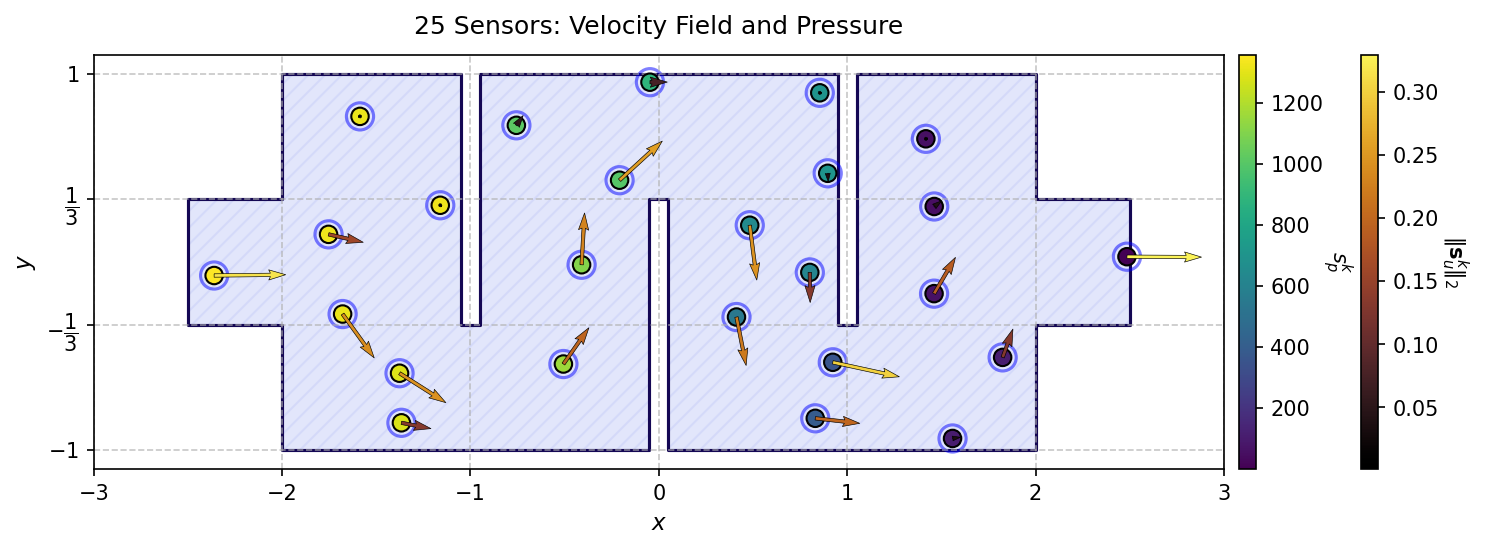

In [22]:
sensors = np.load('Saved_computational_files/sensor_locations.npy')
main_region = np.array([
    [ 0.95,  1.0],
    [ 0.95, -1/3],
    [ 1.05, -1/3],
    [ 1.05,  1.0],
    [ 2.00,  1.0],
    [ 2.00,  1/3],
    [ 2.50,  1/3],
    [ 2.50, -1/3],
    [ 2.00, -1/3],
    [ 2.00, -1.0],
    [ 0.05, -1.0],
    [ 0.05,  1/3],
    [-0.05,  1/3],
    [-0.05, -1.0],
    [-2.00, -1.0],
    [-2.00, -1/3],
    [-2.50, -1/3],
    [-2.50,  1/3],
    [-2.00,  1/3],
    [-2.00,  1.0],
    [-1.05,  1.0],
    [-1.05, -1/3],
    [-0.95, -1/3],
    [-0.95,  1.0],
    [ 0.95,  1.0]
])

fig, ax = plt.subplots(figsize=(10, 4), dpi=150)

ax.plot(main_region[:, 0], main_region[:, 1], color="#140754", linewidth=1.5, zorder=1, label='Domain Boundary')
ax.fill(main_region[:, 0], main_region[:, 1], color="#c7cef8", hatch='///', alpha=0.5, zorder=0)
sc = ax.scatter(sensors[:, 0], sensors[:, 1], c=p_sensor_vals_rom, cmap='viridis', s=70, edgecolors='black', linewidth=1, zorder=3)
ax.scatter(sensors[:, 0], sensors[:, 1], s=170, alpha=0.5, linewidths=1.5, facecolors='none', edgecolors='blue', zorder=1)

u_vec = vectors_rom[:, 0]
v_vec = vectors_rom[:, 1]
speed = np.sqrt(u_vec**2 + v_vec**2)
quiv = ax.quiver(sensors[:, 0], sensors[:, 1], u_vec, v_vec, speed, cmap=cmr.amber, 
                 edgecolor='black', linewidth=0.3, zorder=4, width=0.003, scale=5, label='Velocity')

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="1.5%", pad=0.1) 
cbar = plt.colorbar(sc, cax=cax)
cbar.set_label('$s^k_p$', rotation=270, labelpad=15)

cax_u = divider.append_axes("right", size="1.5%", pad=0.7) 
cbar_u = plt.colorbar(quiv, cax=cax_u)
cbar_u.set_label(r'$\|\mathbf{s}^k_u\|_2$', rotation=270, labelpad=15)

ax.set_aspect('equal')
ax.set_title("25 Sensors: Velocity Field and Pressure", pad=10)
ax.set_xticks(np.linspace(-3, 3, 7))
ax.set_yticks([-1, -1/3, 1/3, 1])
ax.set_yticklabels(['$-1$', '$-\\dfrac{1}{3}$', '$\\dfrac{1}{3}$', '$1$'])
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_xlabel('$x$', fontsize=11)
ax.set_ylabel('$y$', fontsize=11)

plt.tight_layout()
plt.savefig("Outputs/Sensors_Measurement.png", dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.show()